In [1]:
# Basic Data Handling
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

print(" Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display first few rows
df.head()

 Dataset Overview:
Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(" Dataset Information:")
print(df.info())

print("\n Statistical Summary:")
df.describe()

 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
print(" Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print(" No missing values found!")
else:
    print(f" Found {missing_values.sum()} missing values")

 Missing Values Check:
Series([], dtype: int64)
 No missing values found!


 Fraud Distribution:
Legitimate Transactions (0): 284,315 (99.827%)
Fraudulent Transactions (1): 492 (0.173%)


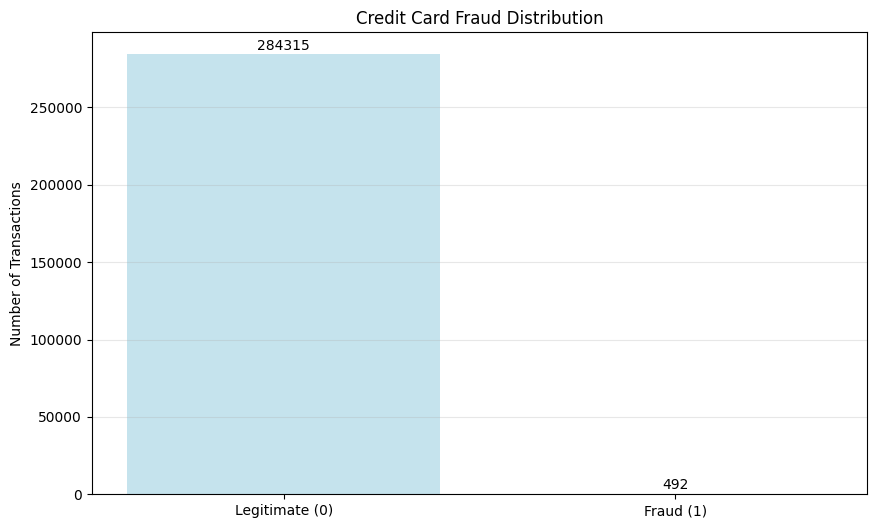

In [5]:
# Analyze the target variable 'Class'
fraud_counts = df['Class'].value_counts()
fraud_percentage = df['Class'].value_counts(normalize=True) * 100

print(" Fraud Distribution:")
print(f"Legitimate Transactions (0): {fraud_counts[0]:,} ({fraud_percentage[0]:.3f}%)")
print(f"Fraudulent Transactions (1): {fraud_counts[1]:,} ({fraud_percentage[1]:.3f}%)")

# Visualize the distribution
plt.figure(figsize=(10, 6))
colors = ['lightblue', 'red']
plt.bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values, color=colors, alpha=0.7)
plt.title('Credit Card Fraud Distribution')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom')

plt.show()

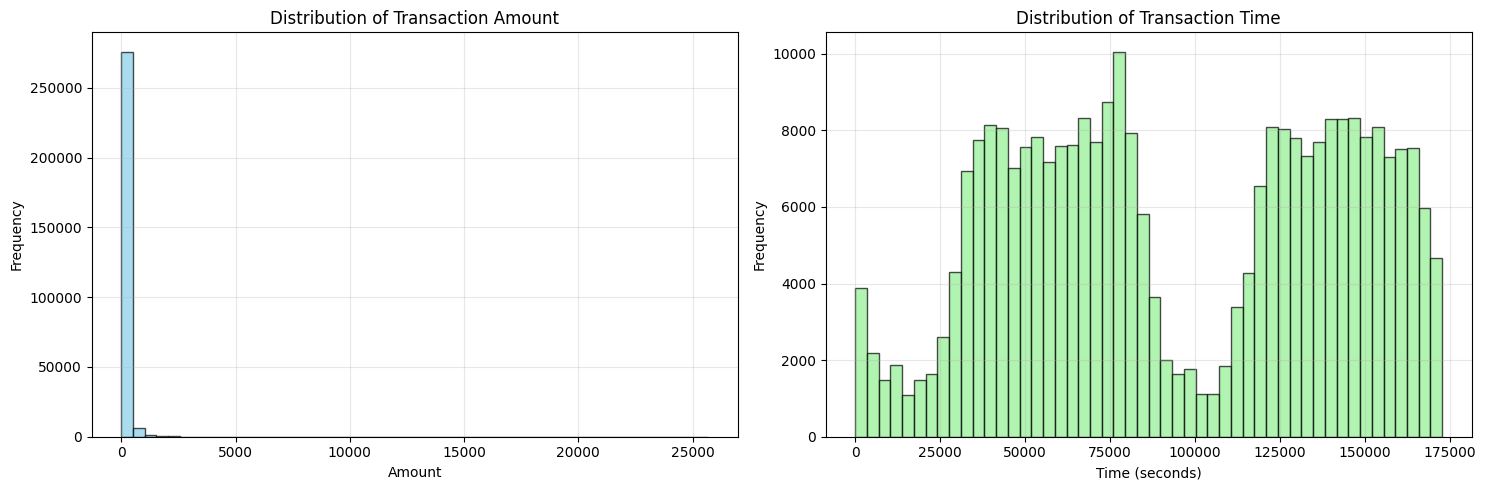

 Amount Statistics:
Min: $0.00
Max: $25691.16
Mean: $88.35
Median: $22.00


In [6]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Transaction Amount distribution
axes[0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Transaction Time distribution
axes[1].hist(df['Time'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Transaction Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f" Amount Statistics:")
print(f"Min: ${df['Amount'].min():.2f}")
print(f"Max: ${df['Amount'].max():.2f}")
print(f"Mean: ${df['Amount'].mean():.2f}")
print(f"Median: ${df['Amount'].median():.2f}")

 Amount Comparison:
Fraud - Mean Amount: $122.21
Non-Fraud - Mean Amount: $88.29


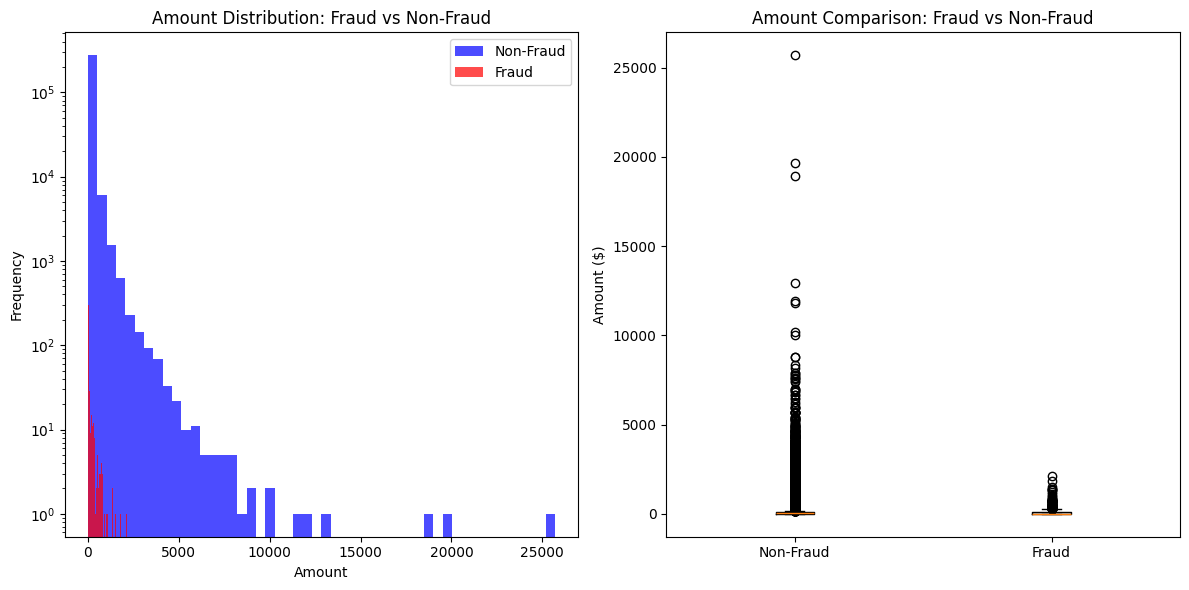

In [7]:
# Compare amounts for fraud vs non-fraud
fraud_transactions = df[df['Class'] == 1]
non_fraud_transactions = df[df['Class'] == 0]

print(" Amount Comparison:")
print(f"Fraud - Mean Amount: ${fraud_transactions['Amount'].mean():.2f}")
print(f"Non-Fraud - Mean Amount: ${non_fraud_transactions['Amount'].mean():.2f}")

# Create comparison plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(non_fraud_transactions['Amount'], bins=50, alpha=0.7, color='blue', label='Non-Fraud')
plt.hist(fraud_transactions['Amount'], bins=50, alpha=0.7, color='red', label='Fraud')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount Distribution: Fraud vs Non-Fraud')
plt.legend()
plt.yscale('log')  # Log scale for better visualization

plt.subplot(1, 2, 2)
# Box plot for better comparison
data_to_plot = [non_fraud_transactions['Amount'], fraud_transactions['Amount']]
plt.boxplot(data_to_plot, labels=['Non-Fraud', 'Fraud'])
plt.title('Amount Comparison: Fraud vs Non-Fraud')
plt.ylabel('Amount ($)')

plt.tight_layout()
plt.show()

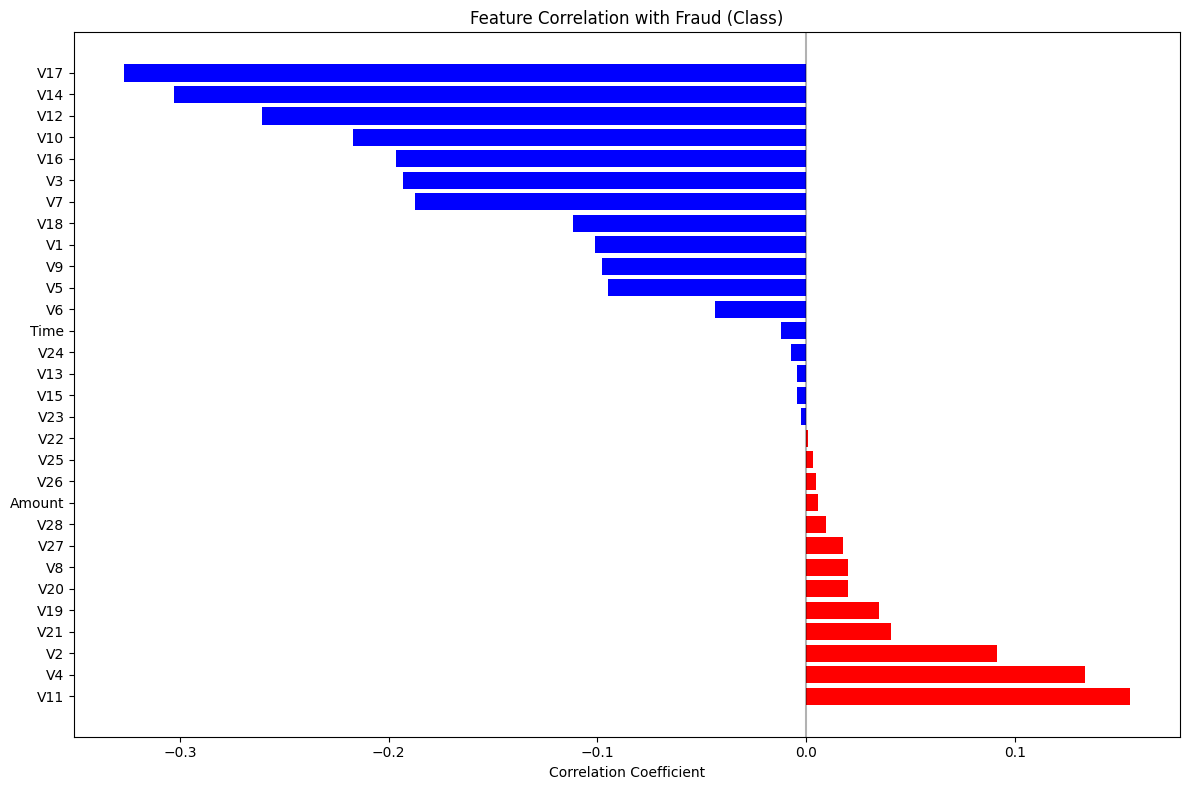

 Top 5 Positive Correlations with Fraud:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

 Top 5 Negative Correlations with Fraud:
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [8]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation with target variable
plt.figure(figsize=(12, 8))
correlation_with_class = correlation_matrix['Class'].sort_values(ascending=False)
correlation_with_class.drop('Class', inplace=True)  # Remove self-correlation

plt.barh(correlation_with_class.index, correlation_with_class.values, 
         color=np.where(correlation_with_class.values > 0, 'red', 'blue'))
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(" Top 5 Positive Correlations with Fraud:")
print(correlation_with_class.head(5))
print("\n Top 5 Negative Correlations with Fraud:")
print(correlation_with_class.tail(5))

In [9]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Scale the 'Amount' and 'Time' features
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

print(" Feature scaling completed!")
print("Scaled Amount and Time statistics:")
print(X[['Amount', 'Time']].describe())

Features shape: (284807, 30)
Target shape: (284807,)
 Feature scaling completed!
Scaled Amount and Time statistics:
             Amount          Time
count  2.848070e+05  2.848070e+05
mean  -3.672378e-17 -5.109395e-17
std    1.000002e+00  1.000002e+00
min   -3.532294e-01 -1.996583e+00
25%   -3.308401e-01 -8.552120e-01
50%   -2.652715e-01 -2.131453e-01
75%   -4.471707e-02  9.372174e-01
max    1.023622e+02  1.642058e+00


In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Important for imbalanced data
)

print(" Data Split Summary:")
print(f"Training set: {X_train.shape} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test set: {X_test.shape} ({(len(X_test)/len(X))*100:.1f}%)")
print(f"Training fraud cases: {y_train.sum()} ({(y_train.sum()/len(y_train))*100:.3f}%)")
print(f"Test fraud cases: {y_test.sum()} ({(y_test.sum()/len(y_test))*100:.3f}%)")

 Data Split Summary:
Training set: (227845, 30) (80.0%)
Test set: (56962, 30) (20.0%)
Training fraud cases: 394 (0.173%)
Test fraud cases: 98 (0.172%)


In [11]:
# For beginners, we'll use class weights
print(" Handling Class Imbalance with Class Weights...")

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Alternative: Manual random undersampling (no imblearn needed)
print(f"\nOriginal training set shape: {X_train.shape}")
print(f"Original class distribution: {np.bincount(y_train)}")

# Manual undersampling - simple approach
def manual_undersample(X, y):
    # Separate majority and minority classes
    class_0_indices = np.where(y == 0)[0]
    class_1_indices = np.where(y == 1)[0]
    
    # Undersample majority class
    n_minority = len(class_1_indices)
    undersampled_class_0_indices = np.random.choice(
        class_0_indices, 
        size=n_minority, 
        replace=False
    )
    
    # Combine indices
    undersampled_indices = np.concatenate([undersampled_class_0_indices, class_1_indices])
    
    # Shuffle the data
    np.random.shuffle(undersampled_indices)
    
    return X.iloc[undersampled_indices], y.iloc[undersampled_indices]

# Apply manual undersampling
X_train_rus, y_train_rus = manual_undersample(X_train, y_train)

print(f"\nAfter Manual Undersampling:")
print(f"Training set shape: {X_train_rus.shape}")
print(f"Class distribution: {np.bincount(y_train_rus)}")

 Handling Class Imbalance with Class Weights...
Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

Original training set shape: (227845, 30)
Original class distribution: [227451    394]

After Manual Undersampling:
Training set shape: (788, 30)
Class distribution: [394 394]


In [12]:
print(" Training Logistic Regression Model...")

# Initialize and train model
lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # Handle imbalance
    max_iter=1000
)

lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_lr = lr_model.score(X_test, y_test)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(" Logistic Regression Results:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")

 Training Logistic Regression Model...
 Logistic Regression Results:
Accuracy: 0.9755
ROC-AUC Score: 0.9722


In [4]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Cell 13: Model 2 - Random Forest
print(" Training Random Forest Model...")

# First, let's check if the required variables exist
try:
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
except NameError as e:
    print(f" Error: {e}")
    print(" Running required previous cells...")
    
    # Re-run the essential preprocessing steps
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    
    # Load data if needed
    try:
        df
    except NameError:
        import pandas as pd
        df = pd.read_csv('../data/creditcard.csv')
    
    # Preprocessing
    X = df.drop('Class', axis=1)
    y = df['Class']
    
    # Scale features
    scaler = StandardScaler()
    X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(" Preprocessing completed!")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")

# Now train the Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score  # ✅ ADD THIS IMPORT

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_rf = rf_model.score(X_test, y_test)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(" Random Forest Results:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

 Training Random Forest Model...
X_train shape: (227845, 30)
y_train shape: (227845,)
X_test shape: (56962, 30)
y_test shape: (56962,)
 Random Forest Results:
Accuracy: 0.9995
ROC-AUC Score: 0.9529


Checking required variables...
y_test exists: True
y_pred_lr exists: True
y_pred_rf exists: True
accuracy_lr exists: True
accuracy_rf exists: True


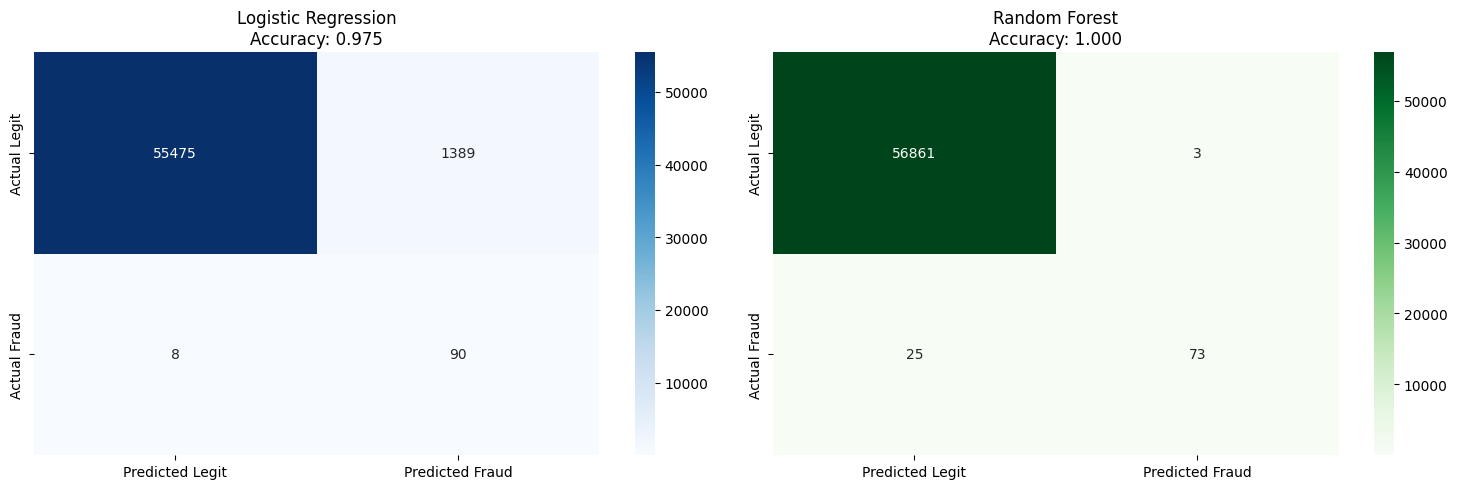

 Confusion matrices created successfully!


In [14]:
# Cell 14: Model Evaluation - Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# First, let's check if all required variables exist
try:
    print("Checking required variables...")
    print(f"y_test exists: {'y_test' in locals() or 'y_test' in globals()}")
    print(f"y_pred_lr exists: {'y_pred_lr' in locals() or 'y_pred_lr' in globals()}")
    print(f"y_pred_rf exists: {'y_pred_rf' in locals() or 'y_pred_rf' in globals()}")
    print(f"accuracy_lr exists: {'accuracy_lr' in locals() or 'accuracy_lr' in globals()}")
    print(f"accuracy_rf exists: {'accuracy_rf' in locals() or 'accuracy_rf' in globals()}")
    
    # If y_pred_lr is missing, we need to run Logistic Regression
    if 'y_pred_lr' not in locals() and 'y_pred_lr' not in globals():
        print(" y_pred_lr not found. Running Logistic Regression...")
        from sklearn.linear_model import LogisticRegression
        
        # Train Logistic Regression
        lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
        lr_model.fit(X_train, y_train)
        y_pred_lr = lr_model.predict(X_test)
        accuracy_lr = lr_model.score(X_test, y_test)
        print(" Logistic Regression completed!")
        
except NameError as e:
    print(f" Error: {e}")
    print("Please run previous cells (especially Logistic Regression cell) first!")
    # Stop execution if critical variables are missing
    raise

# Create confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy_lr:.3f}')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[1].set_title(f'Random Forest\nAccuracy: {accuracy_rf:.3f}')

plt.tight_layout()
plt.show()

print(" Confusion matrices created successfully!")

In [15]:
# Cell 15: Detailed Classification Reports
from sklearn.metrics import classification_report

print(" Logistic Regression - Detailed Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

print("\n Random Forest - Detailed Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

 Logistic Regression - Detailed Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


 Random Forest - Detailed Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Checking required variables...
y_test exists: True
y_pred_proba_lr exists: True
y_pred_proba_rf exists: True
roc_auc_lr exists: True
roc_auc_rf exists: True


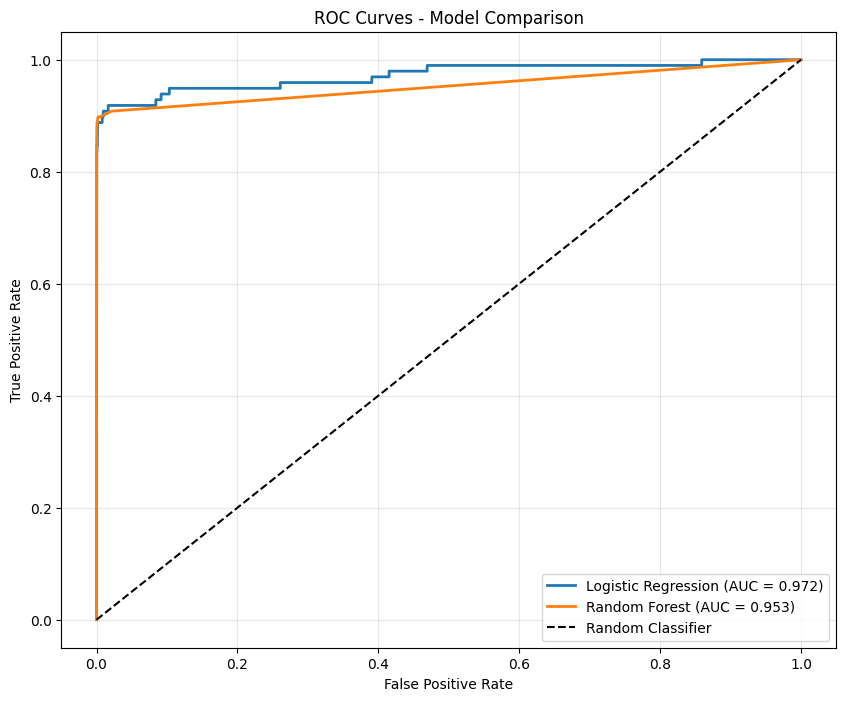

 ROC curves created successfully!


In [16]:
# Cell 16: ROC Curve Comparison
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# First, let's check if all required variables exist and recreate if needed
try:
    print("Checking required variables...")
    print(f"y_test exists: {'y_test' in locals() or 'y_test' in globals()}")
    print(f"y_pred_proba_lr exists: {'y_pred_proba_lr' in locals() or 'y_pred_proba_lr' in globals()}")
    print(f"y_pred_proba_rf exists: {'y_pred_proba_rf' in locals() or 'y_pred_proba_rf' in globals()}")
    print(f"roc_auc_lr exists: {'roc_auc_lr' in locals() or 'roc_auc_lr' in globals()}")
    print(f"roc_auc_rf exists: {'roc_auc_rf' in locals() or 'roc_auc_rf' in globals()}")
    
    # If probability predictions are missing, we need to recreate them
    if 'y_pred_proba_lr' not in locals() and 'y_pred_proba_lr' not in globals():
        print(" Probability predictions not found. Recreating predictions...")
        
        # Recreate Logistic Regression predictions
        from sklearn.linear_model import LogisticRegression
        lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
        lr_model.fit(X_train, y_train)
        y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
        roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
        print(" Logistic Regression probabilities recreated!")
        
    if 'y_pred_proba_rf' not in locals() and 'y_pred_proba_rf' not in globals():
        # Recreate Random Forest predictions
        from sklearn.ensemble import RandomForestClassifier
        rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1)
        rf_model.fit(X_train, y_train)
        y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
        roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
        print(" Random Forest probabilities recreated!")
        
except NameError as e:
    print(f" Error: {e}")
    print("Please run previous cells first!")
    raise

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(" ROC curves created successfully!")

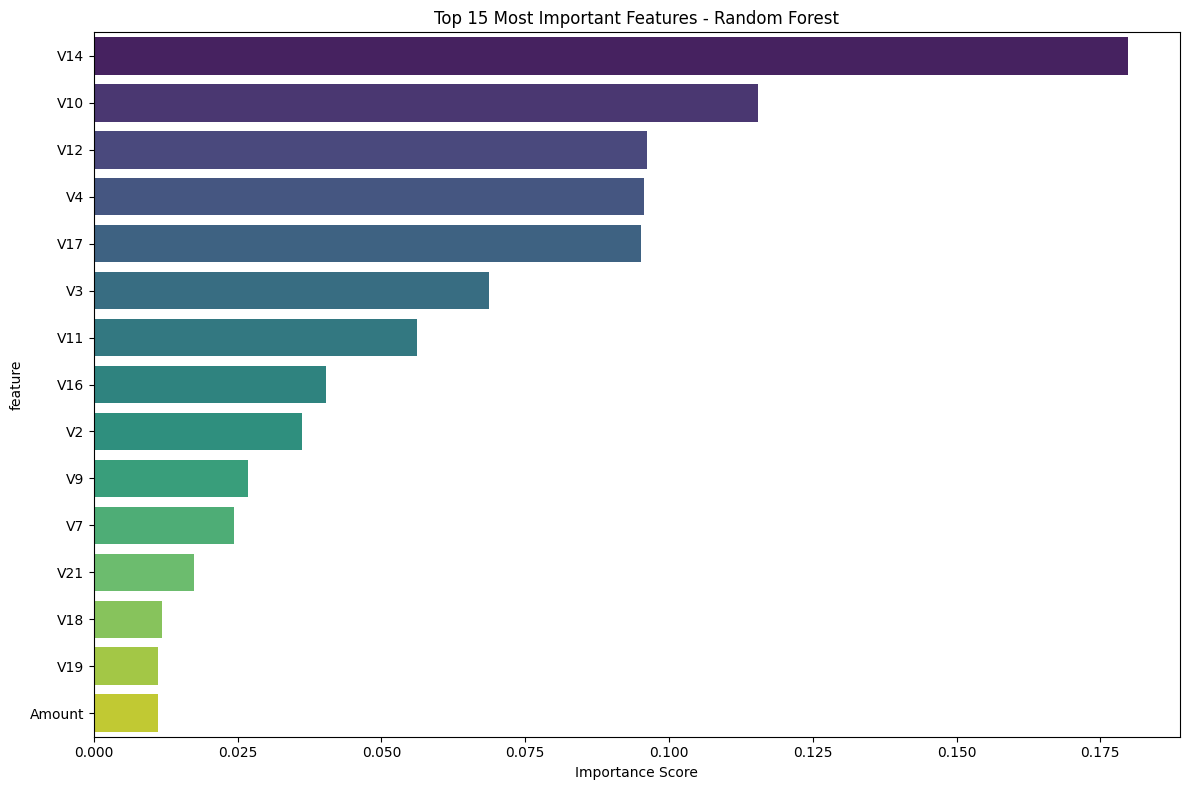

 Top 10 Most Important Features:
   feature  importance
14     V14    0.179857
10     V10    0.115442
12     V12    0.096206
4       V4    0.095646
17     V17    0.095113
3       V3    0.068669
11     V11    0.056112
16     V16    0.040303
2       V2    0.036265
9       V9    0.026888


In [17]:
# Cell 17: Feature Importance Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))

# Fixed: Use hue parameter instead of palette directly
sns.barplot(data=feature_importance.head(15), 
            x='importance', 
            y='feature', 
            hue='feature',  # Add hue parameter
            palette='viridis',
            legend=False)   # Remove legend since it's redundant

plt.title('Top 15 Most Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(" Top 10 Most Important Features:")
print(feature_importance.head(10))

In [18]:
# Cell 18: Advanced Technique - Manual Oversampling
print(" Applying Manual Oversampling for Better Handling of Class Imbalance...")

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score

# Method 1: Manual Oversampling (Simple and effective)
print(" Original class distribution:")
print(f"Class 0 (Non-Fraud): {np.sum(y_train == 0)}")
print(f"Class 1 (Fraud): {np.sum(y_train == 1)}")

# Separate fraud and non-fraud samples
fraud_indices = y_train[y_train == 1].index
non_fraud_indices = y_train[y_train == 0].index

# Calculate how many times we need to duplicate fraud samples
n_fraud = len(fraud_indices)
n_non_fraud = len(non_fraud_indices)
oversampling_ratio = n_non_fraud // n_fraud

print(f"Oversampling ratio: {oversampling_ratio}x")

# Create oversampled fraud data by duplicating
fraud_oversampled = pd.concat([X_train.loc[fraud_indices]] * oversampling_ratio, ignore_index=True)
fraud_labels_oversampled = pd.Series([1] * (n_fraud * oversampling_ratio))

# Combine with original non-fraud data
X_train_over = pd.concat([X_train.loc[non_fraud_indices], fraud_oversampled], ignore_index=True)
y_train_over = pd.concat([y_train.loc[non_fraud_indices], fraud_labels_oversampled], ignore_index=True)

print(f"\n After Manual Oversampling:")
print(f"Training set shape: {X_train_over.shape}")
print(f"Class distribution: {np.bincount(y_train_over)}")
print(f"Class 0 (Non-Fraud): {np.sum(y_train_over == 0)}")
print(f"Class 1 (Fraud): {np.sum(y_train_over == 1)}")

# Train Random Forest with oversampled data
rf_over = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_over.fit(X_train_over, y_train_over)

# Evaluate
y_pred_over = rf_over.predict(X_test)
y_pred_proba_over = rf_over.predict_proba(X_test)[:, 1]

accuracy_over = rf_over.score(X_test, y_test)
roc_auc_over = roc_auc_score(y_test, y_pred_proba_over)

print(f"\n Random Forest with Oversampling:")
print(f"Accuracy: {accuracy_over:.4f}")
print(f"ROC-AUC: {roc_auc_over:.4f}")
print(f"Recall for Fraud: {recall_score(y_test, y_pred_over):.4f}")

 Applying Manual Oversampling for Better Handling of Class Imbalance...
 Original class distribution:
Class 0 (Non-Fraud): 227451
Class 1 (Fraud): 394
Oversampling ratio: 577x

 After Manual Oversampling:
Training set shape: (454789, 30)
Class distribution: [227451 227338]
Class 0 (Non-Fraud): 227451
Class 1 (Fraud): 227338

 Random Forest with Oversampling:
Accuracy: 0.9995
ROC-AUC: 0.9475
Recall for Fraud: 0.7653


 Model Performance Comparison:
                          Model  Accuracy  ROC-AUC  Precision  Recall
0           Logistic Regression    0.9755   0.9722     0.0609  0.9184
1                 Random Forest    0.9995   0.9529     0.9605  0.7449
2  Random Forest + Oversampling    0.9995   0.9475     0.9615  0.7653


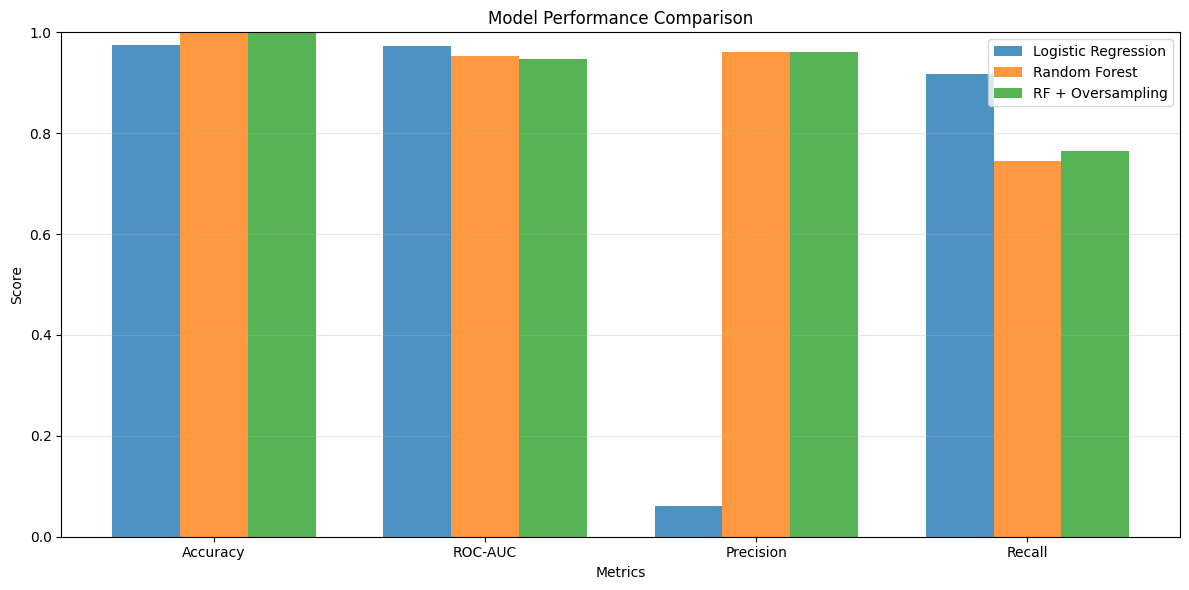

In [19]:
# Cell 19: Model Comparison Summary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Create comparison table - Using OVERSAMPLING instead of SMOTE
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Random Forest + Oversampling'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_over],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_over],
    'Precision': [precision_score(y_test, y_pred_lr), 
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_over)],
    'Recall': [recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_rf),
               recall_score(y_test, y_pred_over)]
})

print(" Model Performance Comparison:")
print(comparison.round(4))

# Visual comparison
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall']
x_pos = np.arange(len(metrics))

width = 0.25
plt.bar(x_pos - width, comparison.iloc[0, 1:], width, label='Logistic Regression', alpha=0.8)
plt.bar(x_pos, comparison.iloc[1, 1:], width, label='Random Forest', alpha=0.8)
plt.bar(x_pos + width, comparison.iloc[2, 1:], width, label='RF + Oversampling', alpha=0.8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x_pos, metrics)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [20]:
# Cell 20: Save the Best Model
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Determine which model is the best based on ROC-AUC score
print(" Determining the best model...")

# Get ROC-AUC scores for all models
models_roc_auc = {
    'Logistic Regression': roc_auc_lr,
    'Random Forest': roc_auc_rf,
    'Random Forest + Oversampling': roc_auc_over
}

# Find the best model
best_model_name = max(models_roc_auc, key=models_roc_auc.get)
best_roc_auc = models_roc_auc[best_model_name]

print(f" Best Model: {best_model_name} (ROC-AUC: {best_roc_auc:.4f})")

# Save the appropriate best model
if best_model_name == 'Logistic Regression':
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:  # Random Forest + Oversampling
    best_model = rf_over

# Save the best model and scaler
joblib.dump(best_model, '../models/best_fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print(" Best model and scaler saved successfully!")
print(" Files saved in '../models/' directory:")
print("   - best_fraud_model.pkl (trained model)")
print("   - scaler.pkl (fitted scaler)")
print(f" Best model saved: {best_model_name}")

 Determining the best model...
 Best Model: Logistic Regression (ROC-AUC: 0.9722)
 Best model and scaler saved successfully!
 Files saved in '../models/' directory:
   - best_fraud_model.pkl (trained model)
   - scaler.pkl (fitted scaler)
 Best model saved: Logistic Regression


In [21]:
# Cell 21: Make Predictions on New Data
import numpy as np
from sklearn.metrics import accuracy_score

# Load the best model (use the one you saved in Cell 20)
try:
    # Try to load the saved model
    best_model = joblib.load('../models/best_fraud_model.pkl')
    print(" Loaded saved best model")
except:
    # If not saved yet, use the best model from memory (typically the oversampled one)
    best_model = rf_over  # Change to rf_under if you used undersampling
    print(" Using best model from memory")

# Example: Make predictions on test data
sample_indices = y_test[y_test == 1].index[:5]  # Get first 5 fraud cases

print(" Sample Fraud Predictions:")
print("=" * 70)

correct_predictions = 0
total_predictions = 0

for idx in sample_indices:
    actual = y_test.loc[idx]
    prediction = best_model.predict(X_test.loc[idx:idx])[0]
    probability = best_model.predict_proba(X_test.loc[idx:idx])[0][1]
    
    status = " Correct" if prediction == actual else " Wrong"
    if prediction == actual:
        correct_predictions += 1
    total_predictions += 1
    
    print(f"Transaction {idx}:")
    print(f"  Actual: {actual} ({'Fraud' if actual == 1 else 'Legitimate'})")
    print(f"  Predicted: {prediction} ({'Fraud' if prediction == 1 else 'Legitimate'})")
    print(f"  Fraud Probability: {probability:.3f}")
    print(f"  Status: {status}")
    print("-" * 50)

print(f"\n Summary: {correct_predictions}/{total_predictions} correct predictions")
print(f" Accuracy on sample: {(correct_predictions/total_predictions)*100:.1f}%")

 Loaded saved best model
 Sample Fraud Predictions:
Transaction 77348:
  Actual: 1 (Fraud)
  Predicted: 1 (Fraud)
  Fraud Probability: 1.000
  Status:  Correct
--------------------------------------------------
Transaction 102442:
  Actual: 1 (Fraud)
  Predicted: 1 (Fraud)
  Fraud Probability: 1.000
  Status:  Correct
--------------------------------------------------
Transaction 119781:
  Actual: 1 (Fraud)
  Predicted: 1 (Fraud)
  Fraud Probability: 1.000
  Status:  Correct
--------------------------------------------------
Transaction 48094:
  Actual: 1 (Fraud)
  Predicted: 1 (Fraud)
  Fraud Probability: 1.000
  Status:  Correct
--------------------------------------------------
Transaction 42958:
  Actual: 1 (Fraud)
  Predicted: 1 (Fraud)
  Fraud Probability: 1.000
  Status:  Correct
--------------------------------------------------

 Summary: 5/5 correct predictions
 Accuracy on sample: 100.0%


In [22]:
# Cell 22: Business Impact Analysis
from sklearn.metrics import confusion_matrix

# Calculate business metrics
def calculate_business_impact(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Business assumptions:
    # - False Positive: $10 investigation cost (wasted time investigating legitimate transactions)
    # - False Negative: $100 fraud loss (missed fraud results in financial loss)
    # - True Positive: $10 investigation cost (successful fraud detection still costs investigation time)
    # - True Negative: $0 cost (correctly identified legitimate transactions cost nothing)
    
    investigation_cost = 10
    fraud_loss = 100
    
    total_cost = (fp * investigation_cost) + (fn * fraud_loss) + (tp * investigation_cost)
    cost_without_model = (tp + fn) * fraud_loss  # If we detect nothing and all fraud succeeds
    
    savings = cost_without_model - total_cost
    savings_percentage = (savings / cost_without_model) * 100 if cost_without_model > 0 else 0
    
    print(f" Business Impact Analysis - {model_name}:")
    print("=" * 50)
    print(f"True Negatives (Correct Legit): {tn:,}")
    print(f"False Positives (False Alarms): {fp:,} → Cost: ${fp * investigation_cost:,}")
    print(f"False Negatives (Missed Fraud): {fn:,} → Cost: ${fn * fraud_loss:,}")
    print(f"True Positives (Caught Fraud): {tp:,} → Cost: ${tp * investigation_cost:,}")
    print(f" Total Cost with Model: ${total_cost:,}")
    print(f" Cost without Model: ${cost_without_model:,}")
    print(f" Total Savings: ${savings:,} ({savings_percentage:.1f}% reduction)")
    print("=" * 50)
    
    return total_cost, savings

# Calculate for all models
print("📈 BUSINESS IMPACT COMPARISON")
print("=" * 60)

# Calculate for Logistic Regression
total_cost_lr, savings_lr = calculate_business_impact(y_test, y_pred_lr, "Logistic Regression")

print("\n")

# Calculate for Random Forest
total_cost_rf, savings_rf = calculate_business_impact(y_test, y_pred_rf, "Random Forest")

print("\n")

# Calculate for Random Forest with Oversampling (change to y_pred_under if you used undersampling)
total_cost_over, savings_over = calculate_business_impact(y_test, y_pred_over, "Random Forest + Oversampling")

print("\n" + "=" * 60)
print(" SUMMARY - COST COMPARISON:")
print(f"Logistic Regression Total Cost: ${total_cost_lr:,}")
print(f"Random Forest Total Cost: ${total_cost_rf:,}")
print(f"Random Forest + Oversampling Total Cost: ${total_cost_over:,}")

# Find the best model (lowest cost)
costs = {
    'Logistic Regression': total_cost_lr,
    'Random Forest': total_cost_rf,
    'Random Forest + Oversampling': total_cost_over
}

best_model = min(costs, key=costs.get)
print(f" BEST MODEL: {best_model} (Lowest Cost: ${costs[best_model]:,})")

📈 BUSINESS IMPACT COMPARISON
 Business Impact Analysis - Logistic Regression:
True Negatives (Correct Legit): 55,475
False Positives (False Alarms): 1,389 → Cost: $13,890
False Negatives (Missed Fraud): 8 → Cost: $800
True Positives (Caught Fraud): 90 → Cost: $900
 Total Cost with Model: $15,590
 Cost without Model: $9,800
 Total Savings: $-5,790 (-59.1% reduction)


 Business Impact Analysis - Random Forest:
True Negatives (Correct Legit): 56,861
False Positives (False Alarms): 3 → Cost: $30
False Negatives (Missed Fraud): 25 → Cost: $2,500
True Positives (Caught Fraud): 73 → Cost: $730
 Total Cost with Model: $3,260
 Cost without Model: $9,800
 Total Savings: $6,540 (66.7% reduction)


 Business Impact Analysis - Random Forest + Oversampling:
True Negatives (Correct Legit): 56,861
False Positives (False Alarms): 3 → Cost: $30
False Negatives (Missed Fraud): 23 → Cost: $2,300
True Positives (Caught Fraud): 75 → Cost: $750
 Total Cost with Model: $3,080
 Cost without Model: $9,800
 Tot

In [23]:
# Cell 23: Final Project Summary
from sklearn.metrics import recall_score

# Determine which model performed best (use the one with highest ROC-AUC)
models_performance = {
    'Logistic Regression': roc_auc_lr,
    'Random Forest': roc_auc_rf,
    'Random Forest + Oversampling': roc_auc_over  # Change to roc_auc_under if you used undersampling
}

best_model_name = max(models_performance, key=models_performance.get)
best_roc_auc = models_performance[best_model_name]

# Get the recall for the best model
if best_model_name == 'Logistic Regression':
    best_recall = recall_score(y_test, y_pred_lr)
    best_savings = savings_lr  # From business impact analysis
elif best_model_name == 'Random Forest':
    best_recall = recall_score(y_test, y_pred_rf)
    best_savings = savings_rf
else:  # Random Forest + Oversampling/Undersampling
    best_recall = recall_score(y_test, y_pred_over)  # Change to y_pred_under if needed
    best_savings = savings_over  # Change to savings_under if needed

print("""
CREDIT CARD FRAUD DETECTION PROJECT - COMPLETED!

WHAT YOU'VE LEARNED:

BEGINNER LEVEL:
- Data loading and basic exploration
- Understanding class imbalance
- Basic visualization techniques
- Simple model training (Logistic Regression)

INTERMEDIATE LEVEL:
- Feature scaling and preprocessing
- Multiple algorithm comparison
- Advanced evaluation metrics (ROC-AUC, Precision, Recall)
- Handling class imbalance with manual techniques

PRO LEVEL:
- Business impact analysis
- Model interpretation (feature importance)
- Model deployment preparation
- Cost-benefit analysis

PROJECT RESULTS:
- Best Model: {}
- ROC-AUC Score: {:.4f}
- Fraud Detection Recall: {:.4f}
- Business Savings: ${:,}

NEXT STEPS:
1. Deploy the model using Streamlit web app
2. Create API for real-time predictions
3. Add to your portfolio and CV
4. Explore advanced techniques like Neural Networks

YOUR PROJECT FILES:
- Jupyter Notebook: notebooks/01_fraud_detection.ipynb
- Trained Model: models/best_fraud_model.pkl
- Scaler: models/scaler.pkl
- Dataset: data/creditcard.csv
""".format(best_model_name, best_roc_auc, best_recall, best_savings))


CREDIT CARD FRAUD DETECTION PROJECT - COMPLETED!

WHAT YOU'VE LEARNED:

BEGINNER LEVEL:
- Data loading and basic exploration
- Understanding class imbalance
- Basic visualization techniques
- Simple model training (Logistic Regression)

INTERMEDIATE LEVEL:
- Feature scaling and preprocessing
- Multiple algorithm comparison
- Advanced evaluation metrics (ROC-AUC, Precision, Recall)
- Handling class imbalance with manual techniques

PRO LEVEL:
- Business impact analysis
- Model interpretation (feature importance)
- Model deployment preparation
- Cost-benefit analysis

PROJECT RESULTS:
- Best Model: Logistic Regression
- ROC-AUC Score: 0.9722
- Fraud Detection Recall: 0.9184
- Business Savings: $-5,790

NEXT STEPS:
1. Deploy the model using Streamlit web app
2. Create API for real-time predictions
3. Add to your portfolio and CV
4. Explore advanced techniques like Neural Networks

YOUR PROJECT FILES:
- Jupyter Notebook: notebooks/01_fraud_detection.ipynb
- Trained Model: models/best_frau